<a href="https://colab.research.google.com/github/SnehaChowdhur/Greetr/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# prompt: import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
df=pd.read_csv("/content/diabetes (2).csv")

In [28]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [29]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [30]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [31]:
print("\nMissing values:\n",df.isnull().sum())


Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [32]:
df.shape

(768, 9)

In [33]:
print("\nMissing values:\n",df.isnull().sum())


Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [34]:
X=df.drop(columns=['Outcome'])
Y=df["Outcome"]

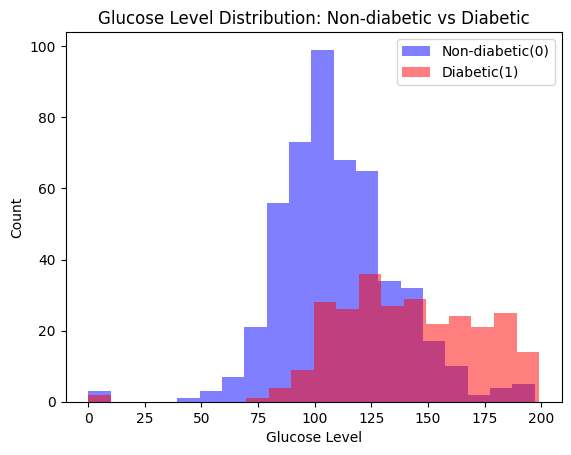

In [35]:
import matplotlib.pyplot as plt
plt.hist(df[df['Outcome']==0]['Glucose'], bins=20, alpha=0.5, label="Non-diabetic(0)", color="blue")
plt.hist(df[df['Outcome']==1]['Glucose'], bins=20, alpha=0.5, label="Diabetic(1)", color="red")
plt.xlabel("Glucose Level")
plt.ylabel("Count")
plt.title("Glucose Level Distribution: Non-diabetic vs Diabetic")
plt.legend()
plt.show()

In [36]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [41]:
scalar=StandardScaler()
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)

In [42]:
#train a SVM Classifier
model=SVC(kernel='linear', C=1.0)
model.fit(x_train,y_train)

#make predictions
y_pred=model.predict(x_test_scaled)


In [43]:
accuracy=accuracy_score(y_test, y_pred)*100
print(f"\nModel accuracy:{accuracy: .2f}%")


Model accuracy: 75.97%


In [44]:
#Classification report
print("\nClassification report:\n",classification_report(y_test,y_pred))


Classification report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



In [45]:
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))


Confusion Matrix:
 [[81 18]
 [19 36]]


In [48]:
#example patient data[pregnencies,glucose,blood pressure,skin thickness,insuline,BMI,DiabetesPedigreeFunction, age]
new_patient=np.array([[2,130,90,45,100,35.0,0.5,55]])

#scale the data
new_patient_scaled=scalar.transform(new_patient)

#Predict
prediction=model.predict(new_patient_scaled)

#Print result
print("\nPredicted Diabetes Outcome for new Patient: ","Diabetic"
  if prediction[0]==1
  else
  "Non Diabetic")


Predicted Diabetes Outcome for new Patient:  Diabetic
